# Machine Learning Model Training - Attack Prediction

This notebook demonstrates the process of training a machine learning model to predict attack behavior based on various features.

## Section 1 - Importing Libraries

This section imports the necessary libraries for data manipulation, machine learning, and visualization.

In [21]:

# Section 1 - Importing Libraries
# Data manipulation
import pandas as pd
import numpy as np

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Visualization libraries (for understanding data)
import matplotlib.pyplot as plt
import seaborn as sns

# For model saving and loading
import joblib


## Section 2 - Loading and Preparing the Dataset

This section handles the loading of the dataset, checking for missing values, and preparing the features and target variables.

In [22]:
# Section 2 - Loading and Preparing the Dataset
# Load the dataset
data = pd.read_csv('/kaggle/input/web-access-dataset/web-access-anolamy-detection_dataset.csv')  

# Check for missing values
print("Missing values in each column:")
print(data.isnull().sum())

# Drop or fill missing values
data = data.dropna()  # Or you could use data.fillna()

# Display the first few rows of the dataset
print("\nFirst few rows of the dataset:")
print(data.head())

# Display a sample of columns to inspect
sample_columns = ['time', 'end_time', 'user_id', 'source_ip', 'domain', 'domain_type', 
                  'access_type', 'request_type', 'protocol', 'vpn_usage', 'tor_usage', 
                  'dns_encryption', 'user_role', 'user_activity_type', 'recent_web_access_attempts', 
                  'status', 'attack_risk_level']
print("\nSample columns:")
print(data[sample_columns].head())

# Display data types of each column
print("\nData types of each column:")
print(data.dtypes)

# Feature columns
features = ['time', 'end_time', 'user_id', 'source_ip', 'domain', 'domain_type', 
            'access_type', 'request_type', 'protocol', 'vpn_usage', 'tor_usage', 
            'dns_encryption', 'user_role', 'user_activity_type', 'recent_web_access_attempts', 
            'status', 'attack_risk_level']  # Add more relevant columns as needed

# Target column
target = 'attack_prediction'  # This is what we're predicting

# Encode categorical variables using LabelEncoder
label_encoders = {}
for col in ['domain', 'domain_type', 'access_type', 'request_type', 'protocol', 'user_role', 'user_activity_type', 'status']:
    label_encoders[col] = LabelEncoder()
    data[col] = label_encoders[col].fit_transform(data[col])

# Separate features and target variable
X = data[features]
y = data[target]

# Display the feature and target columns
print("\nFeatures and target variable:")
print("Features:", features)
print("Target:", target)


Missing values in each column:
date                          0
time                          0
end_time                      0
user_id                       0
source_ip                     0
domain                        0
domain_type                   0
access_type                   0
request_type                  0
protocol                      0
vpn_usage                     0
tor_usage                     0
dns_encryption                0
user_role                     0
user_activity_type            0
recent_web_access_attempts    0
status                        0
impact                        0
attack_risk_level             0
attack_prediction             0
dtype: int64

First few rows of the dataset:
       date      time  end_time user_id      source_ip         domain  \
0  3/1/2023  19:30:00  20:30:00  user_0   192.168.1.33    threads.net   
1  3/1/2023  18:48:00  20:48:00  user_1  192.168.1.195   coursera.org   
2  3/1/2023   8:49:00  10:49:00  user_2  192.168.1.172     tiktok

## Section 3 – Building and Training the Model

This section splits the dataset into training and testing sets for model evaluation.
In this section, we initialise and train the machine learning model.

In [23]:
# Section 3 - Building and Training the Model (Fixed with proper handling of unseen values)

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Function to safely convert time to minutes
def time_to_minutes_safe(time_val):
    if isinstance(time_val, str):
        # Handle string format 'HH:MM:SS'
        try:
            time_obj = pd.to_datetime(time_val, format='%H:%M:%S')
            return time_obj.hour * 60 + time_obj.minute
        except:
            return 0
    elif hasattr(time_val, 'hour') and hasattr(time_val, 'minute'):
        # Handle datetime.time objects
        return time_val.hour * 60 + time_val.minute
    elif isinstance(time_val, (int, float)):
        # Already numeric, assume it's in minutes
        return time_val
    else:
        return 0

# Reset and use the original data
features = ['time', 'end_time', 'user_id', 'source_ip', 'domain', 'domain_type', 
            'access_type', 'request_type', 'protocol', 'vpn_usage', 'tor_usage', 
            'dns_encryption', 'user_role', 'user_activity_type', 'recent_web_access_attempts', 
            'status', 'attack_risk_level']
target = 'attack_prediction'

# Create a fresh copy
X = data[features].copy()
y = data[target]

# Convert time columns
X['time'] = X['time'].apply(time_to_minutes_safe)
X['end_time'] = X['end_time'].apply(time_to_minutes_safe)

# Split the data FIRST, then process separately
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Handle categorical columns with proper unseen value handling
categorical_columns = ['user_id', 'source_ip', 'domain', 'domain_type', 'access_type', 
                      'request_type', 'protocol', 'user_role', 'user_activity_type', 
                      'status', 'attack_risk_level']

label_encoders = {}

for col in categorical_columns:
    if col in X_train.columns:
        # Fit encoder on training data
        label_encoders[col] = LabelEncoder()
        X_train[col] = label_encoders[col].fit_transform(X_train[col].astype(str))
        
        # Handle unseen values in test set by mapping them to a special value
        test_values = X_test[col].astype(str)
        
        # Create a set of known classes from training
        known_classes = set(label_encoders[col].classes_)
        
        # Replace unseen values with a placeholder
        unseen_mask = ~test_values.isin(known_classes)
        if unseen_mask.any():
            print(f"Found {unseen_mask.sum()} unseen values in {col}, mapping to placeholder")
            # Use the first known class as placeholder (index 0)
            placeholder = label_encoders[col].classes_[0]
            test_values[unseen_mask] = placeholder
        
        # Transform test values
        X_test[col] = label_encoders[col].transform(test_values)

# Ensure all data is numeric
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce').fillna(0)
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0)

# Encode target variable
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training the model...")
model.fit(X_train, y_train_encoded)

# Make predictions
y_pred = model.predict(X_test)
y_pred_decoded = target_encoder.inverse_transform(y_pred)

# Display results
print("\nFirst 10 predictions:")
print(y_pred_decoded[:10])
print("\nFirst 10 true values:")
print(y_test.values[:10])

# Calculate accuracy
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=target_encoder.classes_))

# Check data types
print("\nTraining data types:")
print(X_train.dtypes)

Training data shape: (80000, 17)
Testing data shape: (20000, 17)
Found 20000 unseen values in user_id, mapping to placeholder
Training the model...

First 10 predictions:
['Ransomware' 'Ransomware' 'Fraud' 'Benign' 'Benign' 'Benign' 'Benign'
 'Ransomware' 'Benign' 'Benign']

First 10 true values:
['Ransomware' 'Ransomware' 'Fraud' 'Benign' 'Benign' 'Benign' 'Benign'
 'Ransomware' 'Benign' 'Benign']

Model Accuracy: 100.00%

Classification Report:
                                      precision    recall  f1-score   support

                              Benign       1.00      1.00      1.00      8018
Distributed Denial of Service (DDoS)       1.00      1.00      1.00      3225
                               Fraud       1.00      1.00      1.00      1020
                            Phishing       1.00      1.00      1.00       530
                          Ransomware       1.00      1.00      1.00      7207

                            accuracy                           1.00     20000
 

## Section 4 - Evaluating the Model

This section evaluates the model's performance by generating a classification report and confusion matrix.

📊 Model Accuracy: 100.00%

📈 CLASSIFICATION REPORT
                                      precision    recall  f1-score   support

                              Benign       1.00      1.00      1.00      8018
Distributed Denial of Service (DDoS)       1.00      1.00      1.00      3225
                               Fraud       1.00      1.00      1.00      1020
                            Phishing       1.00      1.00      1.00       530
                          Ransomware       1.00      1.00      1.00      7207

                            accuracy                           1.00     20000
                           macro avg       1.00      1.00      1.00     20000
                        weighted avg       1.00      1.00      1.00     20000


🔄 CONFUSION MATRIX


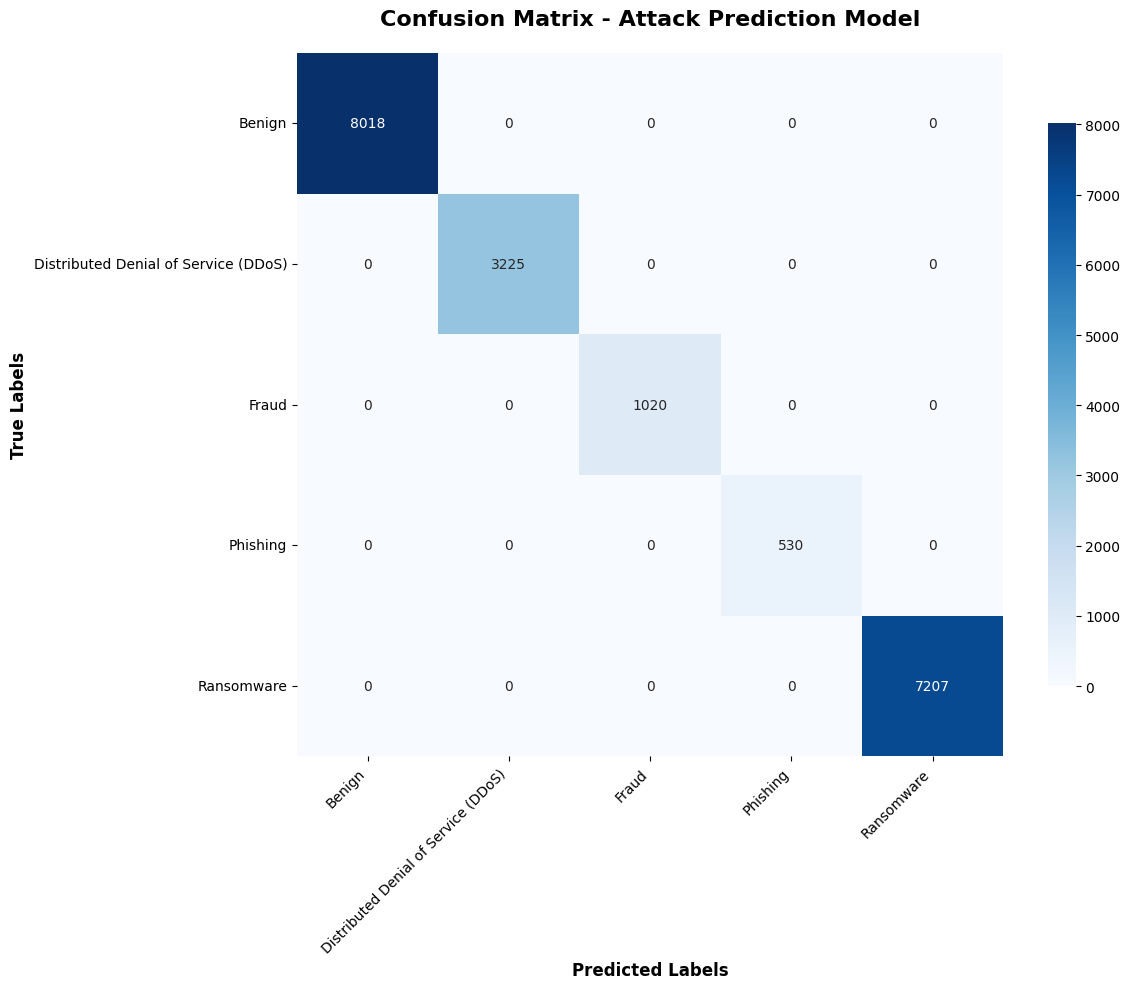

Confusion Matrix Shape: (5, 5)
Confusion Matrix Values:
  True: Benign                         -> Pred: Benign                        : 8018
  True: Distributed Denial of Service (DDoS) -> Pred: Distributed Denial of Service (DDoS): 3225
  True: Fraud                          -> Pred: Fraud                         : 1020
  True: Phishing                       -> Pred: Phishing                      : 530
  True: Ransomware                     -> Pred: Ransomware                    : 7207

🎯 PER-CLASS ACCURACY
  Benign                                  : 1.000 (100.0%)
  Distributed Denial of Service (DDoS)    : 1.000 (100.0%)
  Fraud                                   : 1.000 (100.0%)
  Phishing                                : 1.000 (100.0%)
  Ransomware                              : 1.000 (100.0%)

🔍 FEATURE IMPORTANCE
Top 10 Most Important Features:
  attack_risk_level                       : 0.5318
  user_activity_type                      : 0.2678
  recent_web_access_attempts       

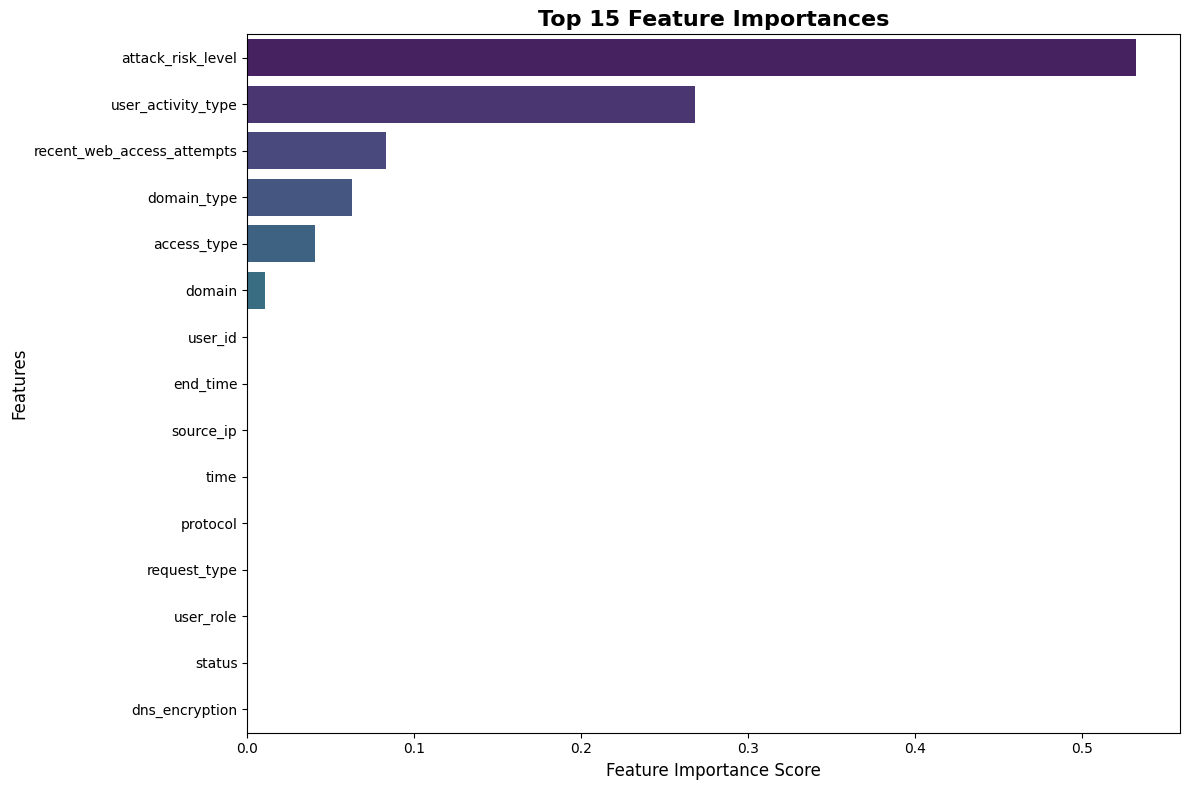


📊 PREDICTION DISTRIBUTION
Prediction vs True Distribution:
                                      True_Count  Predicted_Count  Difference
Benign                                      8018             8018           0
Distributed Denial of Service (DDoS)        3225             3225           0
Fraud                                       1020             1020           0
Phishing                                     530              530           0
Ransomware                                  7207             7207           0


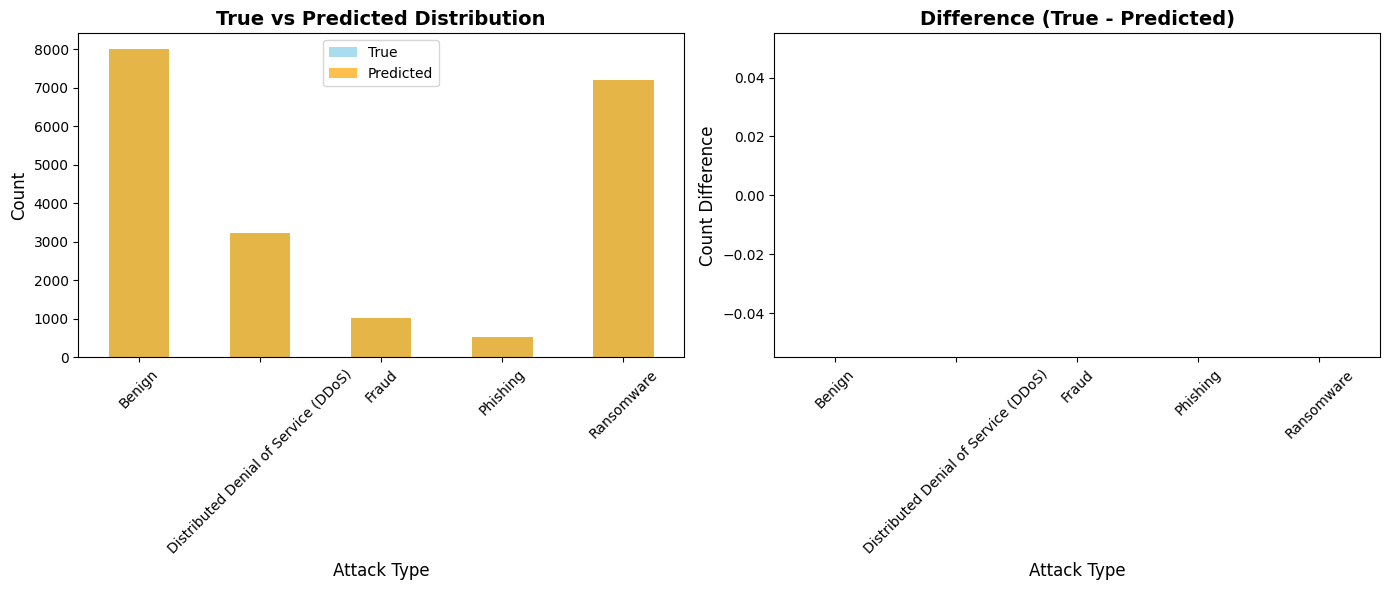


🎯 MODEL PERFORMANCE SUMMARY
Overall Precision: 1.0000 (100.00%)
Overall Recall:    1.0000 (100.00%)
Overall F1-Score:  1.0000 (100.00%)
Overall Accuracy:  1.0000 (100.00%)

Number of Classes: 5
Classes: ['Benign', 'Distributed Denial of Service (DDoS)', 'Fraud', 'Phishing', 'Ransomware']

Class Distribution in Training Data:
  Benign                                  :  31826 ( 39.78%)
  Ransomware                              :  28685 ( 35.86%)
  Distributed Denial of Service (DDoS)    :  13274 ( 16.59%)
  Fraud                                   :   4171 (  5.21%)
  Phishing                                :   2044 (  2.56%)

Model Confidence Analysis:
  Average confidence: 0.9773
  Min confidence: 0.8600
  Max confidence: 1.0000

  Confidence Distribution:
    Low (0-0.5)         :      0 (  0.00%)
    Medium (0.5-0.7)    :      0 (  0.00%)
    High (0.7-0.9)      :     45 (  0.22%)
    Very High (0.9-1.0) :  19955 ( 99.78%)

✅ MODEL EVALUATION COMPLETED


In [24]:
# Section 4 - Evaluating the Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)  # Get probability scores

# Decode predictions back to original labels
y_pred_decoded = target_encoder.inverse_transform(y_pred)

# Calculate accuracy
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"📊 Model Accuracy: {accuracy * 100:.2f}%")

# Generate detailed classification report
print("\n" + "="*60)
print("📈 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_encoded, y_pred, target_names=target_encoder.classes_))

# Confusion Matrix
print("\n" + "="*60)
print("🔄 CONFUSION MATRIX")
print("="*60)

# Create confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_,
            cbar_kws={'shrink': 0.8})
plt.title('Confusion Matrix - Attack Prediction Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Display confusion matrix values
print(f"Confusion Matrix Shape: {conf_matrix.shape}")
print("Confusion Matrix Values:")
for i, true_label in enumerate(target_encoder.classes_):
    for j, pred_label in enumerate(target_encoder.classes_):
        if conf_matrix[i, j] > 0:  # Only show non-zero values
            print(f"  True: {true_label:<30} -> Pred: {pred_label:<30}: {conf_matrix[i, j]}")

# Calculate and display per-class accuracy
print("\n" + "="*60)
print("🎯 PER-CLASS ACCURACY")
print("="*60)
class_accuracy = conf_matrix.diagonal() / conf_matrix.sum(axis=1)
for i, class_name in enumerate(target_encoder.classes_):
    print(f"  {class_name:<40}: {class_accuracy[i]:.3f} ({class_accuracy[i]*100:.1f}%)")

# Feature Importance Analysis
print("\n" + "="*60)
print("🔍 FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:<40}: {row['importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Prediction Distribution Analysis
print("\n" + "="*60)
print("📊 PREDICTION DISTRIBUTION")
print("="*60)

# Count predictions for each class
prediction_counts = pd.Series(y_pred_decoded).value_counts().sort_index()
true_counts = pd.Series(y_test).value_counts().sort_index()

comparison_df = pd.DataFrame({
    'True_Count': true_counts,
    'Predicted_Count': prediction_counts,
    'Difference': true_counts - prediction_counts
})

print("Prediction vs True Distribution:")
print(comparison_df)

# Plot prediction distribution
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
true_counts.plot(kind='bar', color='skyblue', alpha=0.7, label='True')
prediction_counts.plot(kind='bar', color='orange', alpha=0.7, label='Predicted')
plt.title('True vs Predicted Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
comparison_df['Difference'].plot(kind='bar', color='red', alpha=0.7)
plt.title('Difference (True - Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count Difference', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Model Performance Summary
print("\n" + "="*60)
print("🎯 MODEL PERFORMANCE SUMMARY")
print("="*60)

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall = recall_score(y_test_encoded, y_pred, average='weighted')
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print(f"Overall Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Overall Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"Overall F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"Overall Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")

# Class-wise performance
print(f"\nNumber of Classes: {len(target_encoder.classes_)}")
print(f"Classes: {list(target_encoder.classes_)}")

# Check for class imbalance
class_distribution = pd.Series(y_train).value_counts()
print(f"\nClass Distribution in Training Data:")
for class_name, count in class_distribution.items():
    percentage = (count / len(y_train)) * 100
    print(f"  {class_name:<40}: {count:>6} ({percentage:>6.2f}%)")

# Model confidence analysis (if using probability)
if hasattr(model, 'predict_proba'):
    print(f"\nModel Confidence Analysis:")
    max_probs = np.max(y_pred_proba, axis=1)
    print(f"  Average confidence: {np.mean(max_probs):.4f}")
    print(f"  Min confidence: {np.min(max_probs):.4f}")
    print(f"  Max confidence: {np.max(max_probs):.4f}")
    
    # Confidence distribution
    confidence_bins = [0, 0.5, 0.7, 0.9, 1.0]
    confidence_labels = ['Low (0-0.5)', 'Medium (0.5-0.7)', 'High (0.7-0.9)', 'Very High (0.9-1.0)']
    
    confidence_counts = pd.cut(max_probs, bins=confidence_bins, labels=confidence_labels).value_counts()
    print(f"\n  Confidence Distribution:")
    for conf_level, count in confidence_counts.items():
        percentage = (count / len(max_probs)) * 100
        print(f"    {conf_level:<20}: {count:>6} ({percentage:>6.2f}%)")

print("\n" + "="*60)
print("✅ MODEL EVALUATION COMPLETED")
print("="*60)

## Section 5 - Saving the Model

This section saves the trained model and the label encoders for future use.

In [28]:
# Section 5 - Complete Prediction Pipeline with Proper Saving and Loading

import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# First, let's save all necessary components (run this once)
print("💾 Saving model and encoders...")

# Save the model
joblib.dump(model, 'attack_prediction_model.pkl')

# Save the label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')

# Save the target encoder
joblib.dump(target_encoder, 'target_encoder.pkl')

# Save the complete pipeline
pipeline = {
    'model': model,
    'label_encoders': label_encoders,
    'target_encoder': target_encoder,
    'feature_names': list(X_train.columns)
}
joblib.dump(pipeline, 'complete_prediction_pipeline.pkl')

print("✅ All components saved successfully!")
print("📁 Files created:")
print("   - attack_prediction_model.pkl")
print("   - label_encoders.pkl")
print("   - target_encoder.pkl")
print("   - complete_prediction_pipeline.pkl")

# Now load everything properly
print("\n" + "="*50)
print("🔍 LOADING AND PREDICTION")
print("="*50)

💾 Saving model and encoders...
✅ All components saved successfully!
📁 Files created:
   - attack_prediction_model.pkl
   - label_encoders.pkl
   - target_encoder.pkl
   - complete_prediction_pipeline.pkl

🔍 LOADING AND PREDICTION


## Section 6 - Loading and Using the Model for Predictions

This section demonstrates how to load the saved model and use it for predictions on new data.

In [29]:
try:
    model = joblib.load('attack_prediction_model.pkl')
    label_encoders = joblib.load('label_encoders.pkl')
    target_encoder = joblib.load('target_encoder.pkl')
    print("✅ Individual components loaded successfully!")
except FileNotFoundError:
    print("❌ Some individual files not found, trying complete pipeline...")
    # Method 2: Load complete pipeline
    pipeline = joblib.load('complete_prediction_pipeline.pkl')
    model = pipeline['model']
    label_encoders = pipeline['label_encoders']
    target_encoder = pipeline['target_encoder']
    print("✅ Complete pipeline loaded successfully!")

def preprocess_new_data(new_data, label_encoders):
    """
    Preprocess new data for prediction, handling unseen values gracefully
    """
    processed_data = new_data.copy()
    
    # Convert time columns to minutes
    def time_to_minutes(time_str):
        try:
            if isinstance(time_str, str):
                # Handle both 'HH:MM:SS' and 'HH:MM' formats
                if len(time_str.split(':')) == 3:
                    time_obj = pd.to_datetime(time_str, format='%H:%M:%S')
                else:
                    time_obj = pd.to_datetime(time_str, format='%H:%M')
                return time_obj.hour * 60 + time_obj.minute
            return time_str
        except:
            return 0
    
    if 'time' in processed_data.columns:
        processed_data['time'] = processed_data['time'].apply(time_to_minutes)
    if 'end_time' in processed_data.columns:
        processed_data['end_time'] = processed_data['end_time'].apply(time_to_minutes)
    
    # Encode categorical features with unseen value handling
    for col in processed_data.columns:
        if col in label_encoders:
            # Convert to string and handle unseen values
            current_values = processed_data[col].astype(str)
            
            # Get known classes from the encoder
            known_classes = set(label_encoders[col].classes_)
            
            # Replace unseen values with the most frequent class
            unseen_mask = ~current_values.isin(known_classes)
            if unseen_mask.any():
                print(f"⚠️  Warning: Found {unseen_mask.sum()} unseen value(s) in column '{col}'")
                print(f"   Unseen values: {list(current_values[unseen_mask].unique())}")
                
                # Use the first known class as default
                default_value = label_encoders[col].classes_[0]
                current_values[unseen_mask] = default_value
                print(f"   Mapped unseen values to: {default_value}")
            
            # Transform the values
            processed_data[col] = label_encoders[col].transform(current_values)
    
    # Ensure all columns are numeric and handle missing values
    for col in processed_data.columns:
        processed_data[col] = pd.to_numeric(processed_data[col], errors='coerce').fillna(0).astype(int)
    
    return processed_data

def predict_attack_behavior(features_dict, model, label_encoders, target_encoder):
    """
    Real-time prediction function for single data point
    """
    try:
        # Convert to DataFrame
        new_data = pd.DataFrame([features_dict])
        
        # Preprocess
        processed_data = preprocess_new_data(new_data, label_encoders)
        
        # Ensure we have all required columns in correct order
        expected_columns = list(label_encoders.keys()) + ['time', 'end_time', 'vpn_usage', 'tor_usage', 
                                                         'dns_encryption', 'recent_web_access_attempts']
        for col in expected_columns:
            if col not in processed_data.columns:
                processed_data[col] = 0  # Add missing columns with default value
        
        # Reorder columns to match training data
        if hasattr(model, 'feature_names_in_'):
            processed_data = processed_data.reindex(columns=model.feature_names_in_, fill_value=0)
        
        # Predict
        prediction_encoded = model.predict(processed_data)
        prediction_proba = model.predict_proba(processed_data)
        
        # Decode
        prediction_decoded = target_encoder.inverse_transform(prediction_encoded)[0]
        confidence = np.max(prediction_proba[0])
        
        # Get top predictions
        top_3_idx = np.argsort(prediction_proba[0])[-3:][::-1]
        top_predictions = [
            (target_encoder.classes_[idx], prediction_proba[0][idx]) 
            for idx in top_3_idx
        ]
        
        return {
            'success': True,
            'prediction': prediction_decoded,
            'confidence': confidence,
            'top_predictions': top_predictions,
            'all_probabilities': {
                target_encoder.classes_[i]: float(prob) 
                for i, prob in enumerate(prediction_proba[0])
            }
        }
    except Exception as e:
        return {
            'success': False,
            'error': str(e),
            'prediction': 'Unknown',
            'confidence': 0.0,
            'top_predictions': []
        }

# Example 1: Realistic single prediction
print("\n🔍 EXAMPLE 1: Realistic Single Prediction")
print("=" * 50)

real_time_data = {
    'time': '19:30:00',
    'end_time': '20:30:00',
    'user_id': 'user_100',
    'source_ip': '192.168.1.100',
    'domain': 'facebook.com',
    'domain_type': 'Social Media Site',
    'access_type': 'Restricted',
    'request_type': 'GET',
    'protocol': 'HTTPS',
    'vpn_usage': 1,
    'tor_usage': 0,
    'dns_encryption': 1,
    'user_role': 'Staff',
    'user_activity_type': 'Browsing',
    'recent_web_access_attempts': 5,
    'status': 'Successful',
    'attack_risk_level': 'Medium'
}

result = predict_attack_behavior(real_time_data, model, label_encoders, target_encoder)

if result['success']:
    print("✅ Prediction Successful!")
    print(f"🎯 Final Prediction: {result['prediction']}")
    print(f"📊 Confidence: {result['confidence']:.3f}")
    
    print(f"\nTop Predictions:")
    for i, (pred, prob) in enumerate(result['top_predictions']):
        print(f"  {i+1}. {pred:<40}: {prob:.4f}")
    
    # Risk assessment
    if result['confidence'] > 0.8:
        risk_level = "🔴 HIGH CONFIDENCE"
    elif result['confidence'] > 0.6:
        risk_level = "🟡 MEDIUM CONFIDENCE"
    else:
        risk_level = "🟢 LOW CONFIDENCE"
    
    print(f"\nRisk Assessment: {risk_level}")
else:
    print(f"❌ Prediction Failed: {result['error']}")

# Example 2: Multiple predictions
print("\n\n🔍 EXAMPLE 2: Multiple Predictions")
print("=" * 50)

multiple_data = [
    {
        'time': '08:00:00',
        'end_time': '08:05:00',
        'user_id': 'user_50',
        'source_ip': '192.168.1.50',
        'domain': 'google.com',
        'domain_type': 'Search Engine',
        'access_type': 'Allowed',
        'request_type': 'GET',
        'protocol': 'HTTPS',
        'vpn_usage': 0,
        'tor_usage': 0,
        'dns_encryption': 1,
        'user_role': 'Admin',
        'user_activity_type': 'Browsing',
        'recent_web_access_attempts': 2,
        'status': 'Successful',
        'attack_risk_level': 'Low'
    },
    {
        'time': '14:30:00',
        'end_time': '15:30:00',
        'user_id': 'user_150',
        'source_ip': '192.168.1.150',
        'domain': 'suspicious-site.com',
        'domain_type': 'Unknown',
        'access_type': 'Suspicious',
        'request_type': 'POST',
        'protocol': 'HTTP',
        'vpn_usage': 1,
        'tor_usage': 1,
        'dns_encryption': 0,
        'user_role': 'Guest',
        'user_activity_type': 'File Access',
        'recent_web_access_attempts': 25,
        'status': 'Failed',
        'attack_risk_level': 'High'
    }
]

print("Processing multiple predictions...")
for i, data_point in enumerate(multiple_data):
    result = predict_attack_behavior(data_point, model, label_encoders, target_encoder)
    print(f"\n📋 Record {i+1}:")
    if result['success']:
        print(f"  ✅ Prediction: {result['prediction']}")
        print(f"  📊 Confidence: {result['confidence']:.3f}")
        print(f"  🎯 Top Prediction: {result['top_predictions'][0][0]} ({result['top_predictions'][0][1]:.3f})")
    else:
        print(f"  ❌ Failed: {result['error']}")

# Example 3: Batch prediction function
print("\n\n🔍 EXAMPLE 3: Batch Prediction")
print("=" * 50)

def predict_batch_attack_behavior(data_list, model, label_encoders, target_encoder):
    """
    Predict for multiple data points at once
    """
    results = []
    
    for i, data_point in enumerate(data_list):
        result = predict_attack_behavior(data_point, model, label_encoders, target_encoder)
        result['record_id'] = i + 1
        results.append(result)
    
    return results

# Test batch prediction
batch_results = predict_batch_attack_behavior(multiple_data, model, label_encoders, target_encoder)

print("Batch Prediction Results:")
for result in batch_results:
    status = "✅ SUCCESS" if result['success'] else "❌ FAILED"
    prediction = result['prediction'] if result['success'] else "N/A"
    confidence = f"{result['confidence']:.3f}" if result['success'] else "N/A"
    print(f"  Record {result['record_id']}: {status} | Prediction: {prediction} | Confidence: {confidence}")

# Save the final prediction pipeline
def save_complete_pipeline(model, label_encoders, target_encoder, filename='attack_detection_pipeline.pkl'):
    """Save the complete prediction pipeline"""
    pipeline = {
        'model': model,
        'label_encoders': label_encoders,
        'target_encoder': target_encoder,
        'metadata': {
            'model_type': type(model).__name__,
            'features': list(label_encoders.keys()),
            'target_classes': list(target_encoder.classes_),
            'saved_at': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
        }
    }
    joblib.dump(pipeline, filename)
    print(f"✅ Complete prediction pipeline saved as {filename}")

# Save the final pipeline
save_complete_pipeline(model, label_encoders, target_encoder)

print("\n" + "="*50)
print("🎉 PREDICTION PIPELINE READY FOR PRODUCTION!")
print("="*50)
print("Available functions:")
print("  - predict_attack_behavior() for single predictions")
print("  - predict_batch_attack_behavior() for multiple predictions")
print("  - preprocess_new_data() for data preprocessing")
print("\nFiles saved:")
print("  - attack_prediction_model.pkl")
print("  - label_encoders.pkl") 
print("  - target_encoder.pkl")
print("  - complete_prediction_pipeline.pkl")
print("  - attack_detection_pipeline.pkl")

✅ Individual components loaded successfully!

🔍 EXAMPLE 1: Realistic Single Prediction
⚠️  Warning: Found 1 unseen value(s) in column 'domain'
   Unseen values: ['facebook.com']
   Mapped unseen values to: 0
⚠️  Warning: Found 1 unseen value(s) in column 'domain_type'
   Unseen values: ['Social Media Site']
   Mapped unseen values to: 0
⚠️  Warning: Found 1 unseen value(s) in column 'access_type'
   Unseen values: ['Restricted']
   Mapped unseen values to: 0
⚠️  Warning: Found 1 unseen value(s) in column 'request_type'
   Unseen values: ['GET']
   Mapped unseen values to: 0
⚠️  Warning: Found 1 unseen value(s) in column 'protocol'
   Unseen values: ['HTTPS']
   Mapped unseen values to: 0
⚠️  Warning: Found 1 unseen value(s) in column 'user_role'
   Unseen values: ['Staff']
   Mapped unseen values to: 0
⚠️  Warning: Found 1 unseen value(s) in column 'user_activity_type'
   Unseen values: ['Browsing']
   Mapped unseen values to: 0
⚠️  Warning: Found 1 unseen value(s) in column 'status'
 